# <a id='toc1_'></a>[Example workflow in dockerHDDM](#toc0_)

Author: 

- Wanke Pan (panwanke2023@gmail.com) @Nanjing Normal University
- Hu Chuan-Peng (corresponding author, hcp4715@hotmail.com) @Nanjing Normal University
- Ru-Yuan Zhang (corresponding author, ruyuanzhang@sjtu.edu.cn) @Shanghai Jiao Tong University

This is a supplementary notebook for the introductary paper *dockerHDDM: A user-friendly environment for Bayesian Hierarchical Drift-Diffusion Modeling.*. 

This notebook was tested in docker image [`hcp4715/hddm:1.0.1`](https://hub.docker.com/r/hcp4715/hddm/tags), where the packages `kabuki` were rectfied to RC version as below code box.

Preprint of this manuscript: https://psyarxiv.com/6uzga/

Github repository at: https://github.com/hcp4715/dockerHDDM

**Table of contents**<a id='toc0_'></a>    
- [Example workflow in dockerHDDM](#toc1_)    
  - [Loading modules/packages](#toc1_1_)    
  - [Load the example data Cavanaght et al. (2011)](#toc1_2_)    
  - [Model specification and fitting](#toc1_3_)    
  - [Model diagnosis](#toc1_4_)    
    - [Diagnosis of Model 0](#toc1_4_1_)    
      - [Trace plot](#toc1_4_1_1_)    
      - [$\hat{R}$ and ESS](#toc1_4_1_2_)    
    - [Diagnosis of Model 1](#toc1_4_2_)    
      - [Trace plot](#toc1_4_2_1_)    
      - [$\hat{R}$ and ESS](#toc1_4_2_2_)    
    - [Diagnosis of Model 2](#toc1_4_3_)    
      - [Trace plot](#toc1_4_3_1_)    
      - [$\hat{R}$ and ESS](#toc1_4_3_2_)    
      - [non-converge example](#toc1_4_3_3_)    
  - [Model comparison and selection](#toc1_5_)    
    - [DIC](#toc1_5_1_)    
    - [PSIS-LOO-CV](#toc1_5_2_)    
      - [ WAIC](#toc1_5_2_1_)    
      - [PSIS-LOO-CV](#toc1_5_2_2_)    
    - [PSIS issues](#toc1_5_3_)    
  - [Posterior predictive check](#toc1_6_)    
    - [Custom PPC plotting function](#toc1_6_1_)    
  - [Statistical Inference](#toc1_7_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Loading modules/packages](#toc0_)

In [1]:
%matplotlib inline

# scitnific computing and plotting
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# HDDM related packages
import pymc as pm
import hddm
import kabuki
import arviz as az
print("The current HDDM version is: ", hddm.__version__)
print("The current kabuki version is: ", kabuki.__version__)
print("The current PyMC version is: ", pm.__version__)
print("The current ArviZ version is: ", az.__version__)

The current HDDM version is:  1.0.1RC
The current kabuki version is:  0.6.5RC4
The current PyMC version is:  2.3.8
The current ArviZ version is:  0.15.1


## <a id='toc1_2_'></a>[Load the example data Cavanaght et al. (2011)](#toc0_)

The data file is included in HDDM, so we directly load it.

In [87]:
data_cavanagh = hddm.load_csv(hddm.__path__[0] + '/examples/cavanagh_theta_nn.csv')
data_cavanagh.tail()

,subj_idx,stim,rt,response,theta,dbs,conf
3983,13,LL,1.450,0.0,-1.237166,0,HC
3984,13,WL,0.711,1.0,-0.377450,0,LC
3985,13,WL,0.784,1.0,-0.694194,0,LC
3986,13,LL,2.350,0.0,-0.546536,0,HC
3987,13,WW,1.250,1.0,0.752388,0,HC


In [55]:
print("The number of trials: ", data_cavanagh.shape[0])
print("The number of variables: ", data_cavanagh.shape[1])
print("The number of participants: ", data_cavanagh.subj_idx.unique().shape[0])

The number of trials:  3988
The number of variables:  7
The number of participants:  14


## <a id='toc1_3_'></a>[Model specification and fitting](#toc0_)

We define 3 models as below table (Table 2 in main text) from the simplest DDM to full DDM to regression models. Explanation for these three models can be found in **Section "Data and Example Models"** in the main text. 

| Models | HDDM functions for defining a model (`df` is the data from Cavanagh et al., 2011) | # param |
|-|-|-|  
| m0 | hddm.HDDM(df, include=\'a', 'v', 't', *'z', 'sv', 'sz', 'st\]) | 67 |
| m1 | hddm.HDDM(df, include=\['a', 'v', 't','z', 'sv', 'st', 'sz'\], **depends\_on={'v': 'conf'}**) | 82 |
| m2 | hddm.HDDMRegressor(df, **"v ~ C(conf, Treatment('LC'))"**, **group\_only\_regressors=False**, keep\_regressor\_trace=True, include=\['a', 'v', 't', 'z', 'sv', 'st', 'sz'\]) | 83 |

In [56]:
df = data_cavanagh.copy()

# Model 0: base model: full model
m0 = hddm.HDDM(df, include=['a', 'v', 't', 'z', 'sv', 'sz', 'st'])

# Model 1: treat within-subj as between-subj: full model
m1 = hddm.HDDM(df, include=['a', 'v', 't','z', 'sv', 'st', 'sz'], depends_on={'v': 'conf'})

# Model 2: regression model (varying intercept and slope)
m2 = hddm.HDDMRegressor(
  df, "v ~ 1 + C(conf, Treatment('LC'))", 
  include=['a', 'v', 't', 'z', 'sv', 'st', 'sz'], 
  group_only_regressors=False, 
  keep_regressor_trace=True)

No model attribute --> setting up standard HDDM
Set model to full_ddm
No model attribute --> setting up standard HDDM
Set model to full_ddm
No model attribute --> setting up standard HDDM
Set model to full_ddm


Fitting model with new features (parallel sampling and return inferenceData, see [dockerHDDM Quick View](./dockerHDDM_Quick_View.ipynb) and **Section New features in dockerHDDM**). 

We set up 4 MCMC chains with 10,000 samples with 5,000 burn-ins with parallel fitting process and return inferred data for by the code `model.sample(10000, burn = 5000, return_infdata = True)`.

In [57]:
def run_sampling(
    m,
    n_samples=10000,
    n_burn=5000,
    n_chains=4,
    model_name="m",
    progress_bar=True,
):
    """
    Run Markov Chain Monte Carlo (MCMC) sampling for a given model and parameters.
    This function takes a model parameter `m` and runs MCMC sampling using PyMC2.3.8.
    It returns a arviz InferenceData object containing the posterior samples and post-fit model.
    Parameters
    ----------
    m : object
        The model parameter to be sampled.
    n_samples : int, optional
        The number of posterior samples to generate. Default is 10000.
    n_burn : int, optional
        The number of initial samples to discard. Default is 5000.
    n_chains : int, optional
        The number of MCMC chains to run in parallel. Default is 4.
    model_name : str, optional
        The name of the model to be used in the sampling process. Default is "m".
    progress_bar : boolean, optional
        Default=True. Set False hide sampling progress bar. 
    Returns
    -------
    InferenceData : arviz.InferenceData
        A trace object containing the posterior samples.
    Model: HDDM
        A post-fit HDDM model. 
    """

    m_infdata = m.sample(n_samples,
                         burn=n_burn,
                         chains=n_chains,
                         return_infdata=True,
                         save_name="model_fitted/" + model_name,
                         progress_bar=progress_bar)

    return m, m_infdata

**Note: Fitting all these six model with settings above (10000 samples) takes about 8-9 hours on a PC with Intel® Core™ i7-10700 CPU @ 2.90GHz. Also, the memory of should be large enough, ~ 64 G memory is recommended. Otherwise,  recommend few samples (e.g., n_samples=2500, burn=1000).**

In [8]:
%time
m0, m0_infdata = run_sampling(m0, model_name="m0")

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


[                  0%                  ] 2 of 10000 complete in 0.6 sec
[                  0%                  ] 2 of 10000 complete in 0.6 sec
[                  0%                  ] 2 of 10000 complete in 0.7 sec
[                  0%                  ] 2 of 10000 complete in 0.9 sec
[                  0%                  ] 3 of 10000 complete in 1.5 sec
[                  0%                  ] 3 of 10000 complete in 1.5 sec
[                  0%                  ] 3 of 10000 complete in 1.9 sec
[                  0%                  ] 4 of 10000 complete in 2.3 sec
[                  0%                  ] 4 of 10000 complete in 2.3 sec
[                  0%                  ] 3 of 10000 complete in 2.1 sec
[                  0%                  ] 4 of 10000 complete in 2.9 sec
[                  0%                  ] 5 of 10000 complete in 3.2 sec
[                  0%                  ] 5 of 10000 complete in 3.2 sec
[                  0%                  ] 4 of 10000 complete in 

In [9]:
%time
# Set progress_bar=False to hide the program's progress bar to simplify the output
m1, m1_infdata = run_sampling(m1, model_name="m1")

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


hddm sampling elpased time:  7583.042 s
hddm sampling elpased time:  7601.904 s
hddm sampling elpased time:  7612.94 s
hddm sampling elpased time:  7614.274 s
hddm sampling elpased time:  7623.455 s
Start converting to InferenceData...
CPU times: user 7.95 s, sys: 65 ms, total: 8.02 s
Wall time: 2h 7min 4s


In [10]:
%time
# Set progress_bar=False to hide the program's progress bar to simplify the output
m2, m2_infdata = run_sampling(m2, model_name="m2")

/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)
/opt/conda/lib/python3.9/site-packages/scipy/optimize/_optimize.py:2309: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


hddm sampling elpased time:  16445.777 s
hddm sampling elpased time:  16472.208 s
hddm sampling elpased time:  16510.822 s
hddm sampling elpased time:  16599.44 s
hddm sampling elpased time:  16624.156 s
Start converting to InferenceData...
CPU times: user 33.3 s, sys: 944 ms, total: 34.3 s
Wall time: 4h 37min 5s


## <a id='toc1_4_'></a>[Model diagnosis](#toc0_)

We use `az.plot_trace()` to visually check the trace plot of MCMC chains and use `az.summary()` to check $\hat{R}$ and Effective Sample Size (ESS). 

### <a id='toc1_4_1_'></a>[Diagnosis of Model 0](#toc0_)

#### <a id='toc1_4_1_1_'></a>[Trace plot](#toc0_)

We can also only plot selected parameters' traces. 
 
- use regex to select var_names that start with "a" and do not contain either "subj" or "std".

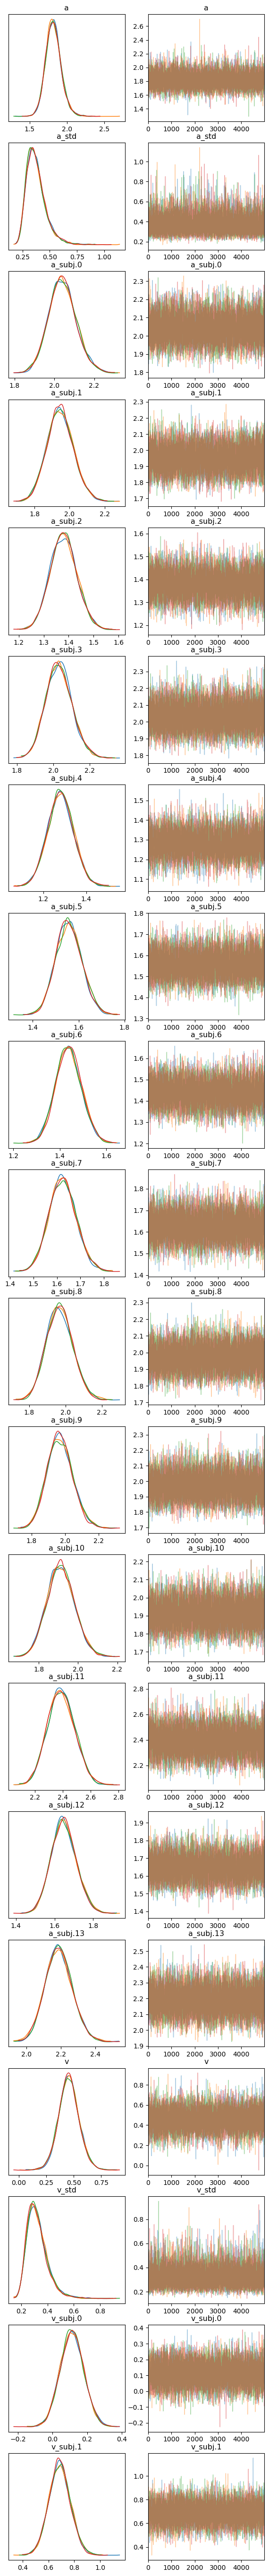

In [10]:
tmp_infdata = m0_infdata
plt.rc('font', size=16)

# plot traces for all parameters
axes = az.plot_trace(tmp_infdata, compact = False, figsize = [7, 70])

/opt/conda/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/traceplot.py:433: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain_id in range(data.dims["chain"])


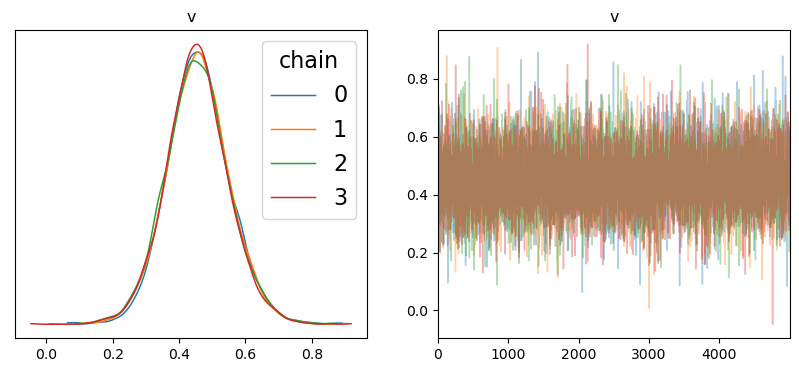

In [50]:
# select population level parameter v as a example
axes = az.plot_trace(
    tmp_infdata, 
    var_names= ('v'), 
    compact = False, 
    legend=True, 
    figsize = [10, 4]
)

/opt/conda/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/traceplot.py:433: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain_id in range(data.dims["chain"])


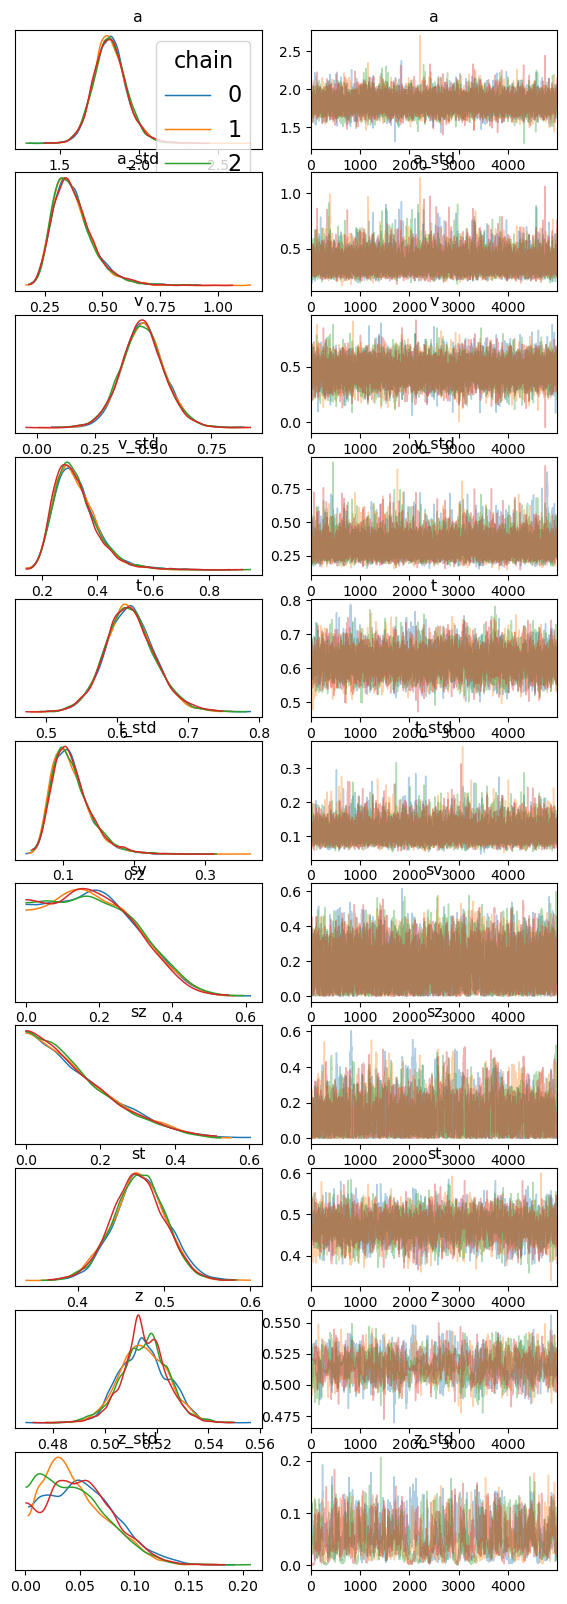

In [12]:
# select all population level parameters
axes = az.plot_trace(
    tmp_infdata, 
    var_names=['~subj'],  # exclude individual level parameters
    filter_vars='regex',
    compact = False, 
    legend=True, 
    figsize = [7, 20]
)

#### <a id='toc1_4_1_2_'></a>[$\hat{R}$ and ESS](#toc0_)

In [13]:
summary_tmp = az.summary(tmp_infdata, kind = "diagnostics", round_to=4)
summary_tmp.sort_values('r_hat', ascending=False).head(10)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_std,0.0013,0.0009,425.5902,451.8641,1.0132
z_subj.10,0.0006,0.0004,718.8918,1516.5931,1.0068
z,0.0004,0.0002,658.0802,1666.0598,1.0052
t_subj.4,0.0005,0.0004,2219.4995,3842.6706,1.0051
z_subj.1,0.0004,0.0003,1137.8897,3817.8410,1.0050
z_subj.11,0.0003,0.0002,1699.4180,5051.1148,1.0045
t_subj.1,0.0008,0.0006,1840.7526,2430.6529,1.0041
z_subj.7,0.0003,0.0002,1814.9990,5060.0522,1.0041
z_subj.13,0.0003,0.0002,1613.6463,4644.7192,1.0039
z_subj.12,0.0004,0.0003,1267.3623,4012.9876,1.0036


In [14]:
# only calculate R hat
az.rhat(tmp_infdata).values

<bound method Mapping.values of <xarray.Dataset> Size: 536B
Dimensions:    ()
Data variables: (12/67)
    a          float64 8B 0.9999
    a_std      float64 8B 1.0
    a_subj.0   float64 8B 1.0
    a_subj.1   float64 8B 1.001
    a_subj.2   float64 8B 1.0
    a_subj.3   float64 8B 1.0
    ...         ...
    z_subj.8   float64 8B 1.003
    z_subj.9   float64 8B 1.003
    z_subj.10  float64 8B 1.007
    z_subj.11  float64 8B 1.004
    z_subj.12  float64 8B 1.004
    z_subj.13  float64 8B 1.004>

In [15]:
# only calculate ESS
az.ess(tmp_infdata).values

<bound method Mapping.values of <xarray.Dataset> Size: 536B
Dimensions:    ()
Data variables: (12/67)
    a          float64 8B 1.146e+04
    a_std      float64 8B 9.267e+03
    a_subj.0   float64 8B 6.142e+03
    a_subj.1   float64 8B 5.001e+03
    a_subj.2   float64 8B 4.876e+03
    a_subj.3   float64 8B 7.017e+03
    ...         ...
    z_subj.8   float64 8B 1.215e+03
    z_subj.9   float64 8B 1.329e+03
    z_subj.10  float64 8B 718.9
    z_subj.11  float64 8B 1.699e+03
    z_subj.12  float64 8B 1.267e+03
    z_subj.13  float64 8B 1.614e+03>

### <a id='toc1_4_2_'></a>[Diagnosis of Model 1](#toc0_)

#### <a id='toc1_4_2_1_'></a>[Trace plot](#toc0_)

In [51]:
tmp_infdata = m1_infdata

# plot traces for all parameters
# axes = az.plot_trace(tmp_infdata, compact = False, figsize = [7, 70])

/opt/conda/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/traceplot.py:433: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain_id in range(data.dims["chain"])


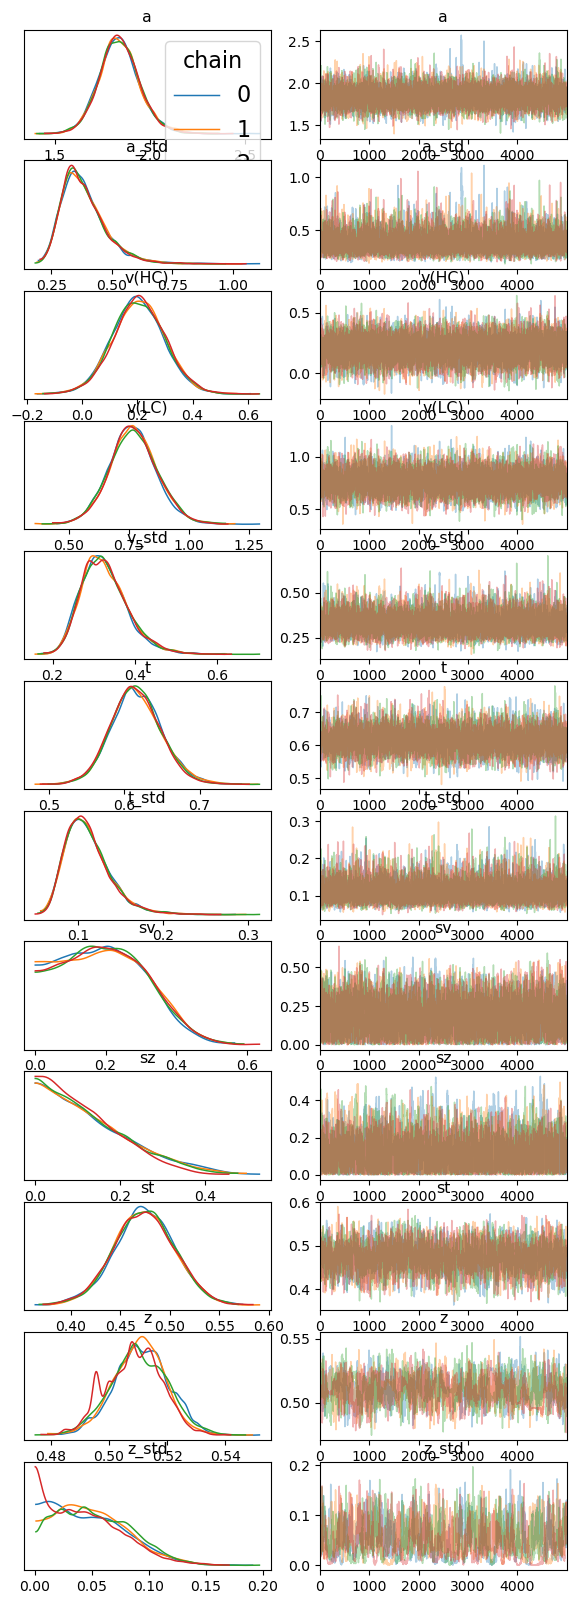

In [17]:
# select all population level parameters
axes = az.plot_trace(
    tmp_infdata, 
    var_names=['~subj'],  # exclude individual level parameters
    filter_vars='regex',
    compact = False, 
    legend=True, 
    figsize = [7, 20]
)

#### <a id='toc1_4_2_2_'></a>[$\hat{R}$ and ESS](#toc0_)

In [18]:
summary_tmp = az.summary(tmp_infdata, kind = "diagnostics", round_to=4)
summary_tmp.sort_values('r_hat', ascending=False).head(10)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_std,0.0017,0.0012,293.8166,239.3520,1.0156
z_subj.10,0.0008,0.0006,503.5108,239.7519,1.0155
z,0.0004,0.0003,470.3783,1122.2618,1.0141
z_subj.8,0.0005,0.0003,852.3467,3019.4751,1.0114
z_subj.4,0.0005,0.0003,933.7400,3623.0933,1.0100
z_subj.1,0.0005,0.0004,795.9172,2886.2517,1.0095
z_subj.13,0.0004,0.0003,956.5060,3530.1094,1.0093
z_subj.12,0.0005,0.0004,844.1818,2766.6764,1.0091
z_subj.2,0.0005,0.0003,949.2420,3695.4760,1.0083
z_subj.3,0.0004,0.0003,1032.1055,4940.5928,1.0063


### <a id='toc1_4_3_'></a>[Diagnosis of Model 2](#toc0_)

#### <a id='toc1_4_3_1_'></a>[Trace plot](#toc0_)

In [21]:
tmp_infdata = m2_infdata

# plot traces for all parameters
# axes = az.plot_trace(tmp_infdata, compact = False, figsize = [7, 70])

/opt/conda/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/traceplot.py:433: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain_id in range(data.dims["chain"])


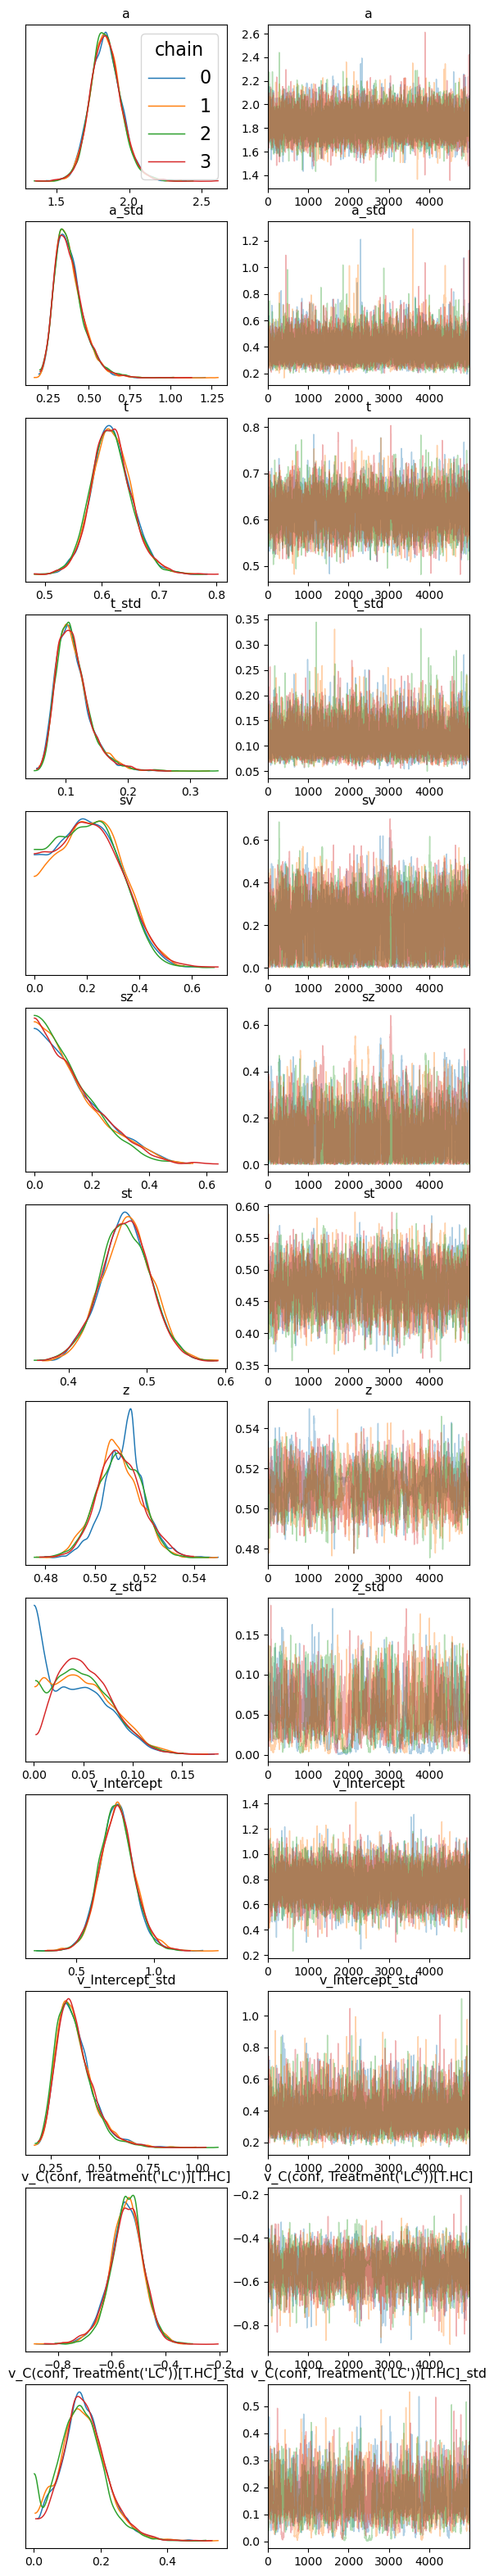

In [22]:
# select all population level parameters
axes = az.plot_trace(
    tmp_infdata, 
    var_names=['~subj'],  # exclude individual level parameters
    filter_vars='regex',
    compact = False, 
    legend=True, 
    figsize = [7, 40]
)

#### <a id='toc1_4_3_2_'></a>[$\hat{R}$ and ESS](#toc0_)

In [23]:
summary_tmp = az.summary(tmp_infdata, kind = "diagnostics", round_to=4)
summary_tmp.sort_values('r_hat', ascending=False).head(10)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_std,0.0017,0.0012,223.5641,186.9666,1.0181
z,0.0003,0.0002,794.9641,1560.2810,1.0095
z_subj.5,0.0005,0.0003,1087.1673,4161.4777,1.0089
z_subj.9,0.0004,0.0003,1198.3803,3666.7282,1.0074
z_subj.6,0.0004,0.0003,1328.7416,4275.4789,1.0068
z_subj.8,0.0004,0.0003,1491.8643,4741.7229,1.0065
z_subj.2,0.0004,0.0002,1584.2258,4922.9620,1.0064
"v_C(conf, Treatment('LC'))[T.HC]_std",0.0024,0.0017,714.8018,450.5181,1.0059
z_subj.12,0.0004,0.0003,1292.8690,4943.5490,1.0055
z_subj.11,0.0003,0.0002,1797.9384,4862.5218,1.0054


#### <a id='toc1_4_3_3_'></a>[non-converge example](#toc0_)

Since `z_std` have $\hat{R}$ > 1.01 and ESS bulk < 400, we double-check these two parameters with a trace plot.

- In terms of the posterior distribution, 'z_std' differ in the consistency of convergence of the four chains and their hdi (highest density interval).
- Since the 'z_std' obeys the truncate distribution, its mean and mode are clustered around 0
- However, from the trace plot, it is clear that 'z_std' has non-converge feature in chain 2 (the long regions of monotonicity like a line parallel to the x-axis).
    - (see 2.4 Diagnosing Numerical Inference in Martin, O.A., et. cl (2021) Bayseian Modeling and Computation in Python).

However, in general, the $\hat{R}$ of the two parameters is close to 1.01, and more broadly speaking, less than 1.1. And the distribution of the chains is still stable and consistent, we think this result is acceptable.

/opt/conda/lib/python3.9/site-packages/arviz/plots/backends/matplotlib/traceplot.py:433: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for chain_id in range(data.dims["chain"])


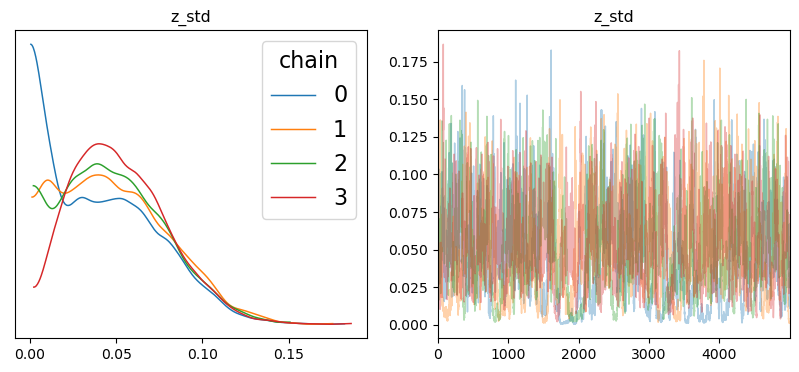

In [42]:
# select `z_std`
axes = az.plot_trace(
    m2_infdata, 
    var_names=['z_std'], 
    compact = False, 
    legend=True, 
    figsize = [10, 4]
)

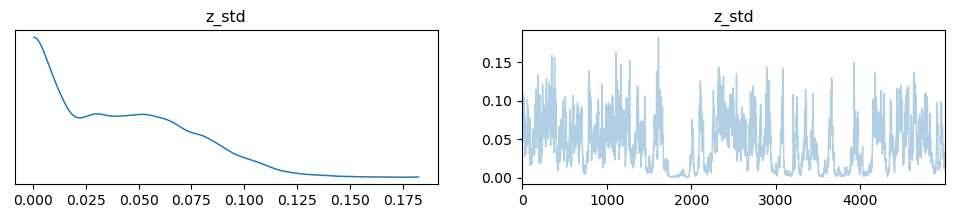

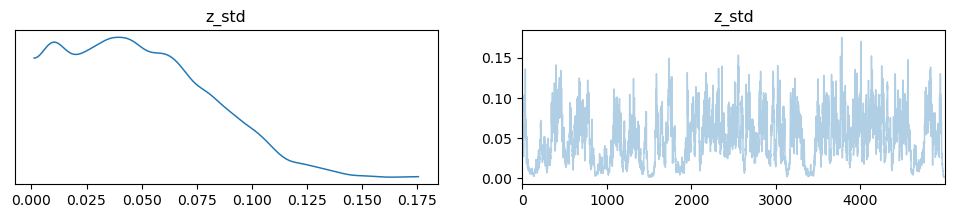

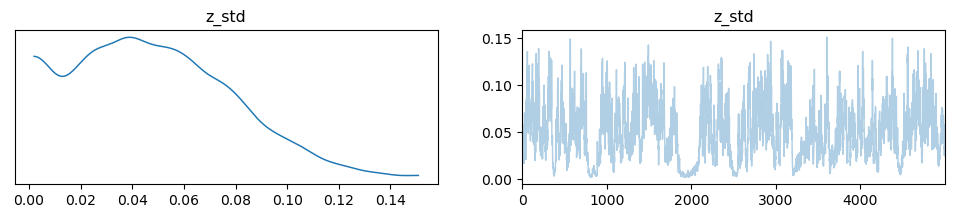

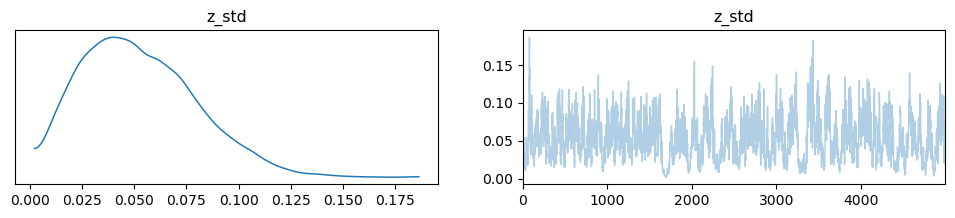

In [27]:
for i in range(4):
    
    az.plot_trace(
        m2_infdata, 
        var_names=['z_std'], 
        coords = {'chain': [i]}, 
        compact = False, 
        combined = False
    )

## <a id='toc1_5_'></a>[Model comparison and selection](#toc0_)

### <a id='toc1_5_1_'></a>[DIC](#toc0_)

Here we retrieve the DIC from each model in the models and sort by DIC.

In [ ]:
dic_dict = {
  "m0(baseline)":m0.dic,
  "m1(v depends on conf)":m1.dic,
  "m2(reg: v ~ 1 + conf)":m2.dic
}

comp_dic = pd.DataFrame.from_dict(dic_dict, orient='index', columns=['DIC'])
comp_dic['model'] = comp_dic.index
comp_dic = comp_dic[['model', 'DIC']]
comp_dic.sort_values(by=['DIC'], ascending = True)

,model,DIC
m2,m2,10654.862529
m1,m1,10655.267937
m0,m0,10835.366914


### <a id='toc1_5_2_'></a>[PSIS-LOO-CV](#toc0_)

To evaluate models with criterions like WAIC and PSIS-LOO-CV, pointwise loglikelihoods are required (see Section Model Comparison in Manuscript). 

The following code shows how to calculate the pointwise loglikelihoods. 

**note**:
- **It can take half an hour or a few hours depending on CPU performance**.
- **If your RAM is less than or equal to 16g, an error may occur**. 

In [29]:
%time
m0_infdata = m0.to_infdata(loglike = True, save_name = "model_fitted/m0")

Start to calculate pointwise log likelihood...
[-----------------100%-----------------] 10001 of 10000 complete in 11003.8 sec
hddm sampling elpased time:  11005.972 s
[-----------------99%----------------- ] 9991 of 10000 complete in 11113.2 sec
[-----------------99%----------------- ] 9992 of 10000 complete in 11114.3 sec
[-----------------99%----------------- ] 9993 of 10000 complete in 11115.5 sec
[-----------------99%----------------- ] 9994 of 10000 complete in 11116.5 sec
[-----------------99%----------------- ] 9995 of 10000 complete in 11117.6 sec
[-----------------99%----------------- ] 9996 of 10000 complete in 11118.5 sec
[-----------------99%----------------- ] 9997 of 10000 complete in 11119.5 sec
[-----------------99%----------------- ] 9998 of 10000 complete in 11120.5 sec
[-----------------99%----------------- ] 9999 of 10000 complete in 11121.4 sec
[-----------------100%-----------------] 10000 of 10000 complete in 11122.5 sec
[-----------------100%-----------------] 

In [30]:
%time
m1_infdata = m1.to_infdata(loglike = True, save_name = "model_fitted/m1")

Start to calculate pointwise log likelihood...
The time of calculation of loglikelihood took 115.769 seconds
Start converting to InferenceData...
CPU times: user 1min 35s, sys: 6.2 s, total: 1min 41s
Wall time: 2min 37s


In [31]:
%time
m2_infdata = m2.to_infdata(loglike = True, save_name = "model_fitted/m2")

Start to calculate pointwise log likelihood...
The time of calculation of loglikelihood took 1402.580 seconds
Start converting to InferenceData...
CPU times: user 1min 40s, sys: 6.36 s, total: 1min 47s
Wall time: 24min 9s


Warining here is caused by large number as input of `exp()`, solution is [here](https://stackoverflow.com/questions/40726490/overflow-error-in-pythons-numpy-exp-function).

In [32]:
compare_dict = {
  "m0":m0_infdata,
  "m1":m1_infdata,
  "m2":m2_infdata
}

#### <a id='toc1_5_2_1_'></a>[ WAIC](#toc0_)

In [34]:
comp_waic = az.compare(compare_dict, ic='waic', scale="deviance")
comp_waic

/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:256: RuntimeWarning: invalid value encountered in double_scalars
  grad[k] += (exp_ic_i[i, k] - exp_ic_i[i, km1]) / np.dot(exp_ic_i[i], w_full)


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
m1,0,24646.549487,6923.830078,0.000000,0.333333,7141.400609,0.000000,True,deviance
m2,1,24683.121824,6937.783845,36.572336,0.333333,7292.176469,710.980231,True,deviance
m0,2,26076.361080,7537.594727,1429.811593,0.333333,7580.282609,777.451108,True,deviance


#### <a id='toc1_5_2_2_'></a>[PSIS-LOO-CV](#toc0_)

In [33]:
comp_loo = az.compare(compare_dict, ic='loo', scale="deviance")
comp_loo

/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: invalid value encountered in double_scalars
  sigma = -k_post / b_post
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: inv

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m2,0,15897.784567,2545.115217,0.0,0.333333,2287.481373,0.0,True,deviance
m0,1,NaN,NaN,NaN,0.333333,NaN,NaN,True,deviance
m1,2,NaN,NaN,NaN,0.333333,NaN,NaN,True,deviance


### <a id='toc1_5_3_'></a>[PSIS issues](#toc0_)

**Warnings**: The above result shows that m0 and m1 are unable to compute PSIS-LOO-CV(elpd_loo), this is because of the overflow encountered in some calculation as the above warnings. 

As follow, we can check pareto_k $\hat{k}$. If $\hat{k} >  0.7$, which means importance sampling (PSIS) is not able to provide useful estimate for that component/observation. Highly influential observations have high $\hat{k}$ values. Very high $\hat{k}$ values often indicate model misspecification, outliers or mistakes in data processing.

Also, `p_loo`is large than *p*, which is number of parameters of the model. Large `p_loo` means the model is badly misspecified according to Aki Vehtari's [Q & A](https://avehtari.github.io/modelselection/CV-FAQ.html#18_What_is_the_interpretation_of_p_loo). For all models, the *N*, number of obersvations, is 3988, and the number of parameters varies from 48 to 83. Thus, `p_loo` is much larger than numbers of parameters for all models.

As we can from below, this was primarily because of a few outliers. As HDDM allow for 5 percent of outliers in modelling, it is not surprising that these outliers stronly influenced the model performance. Here, we remove the outliers from all models and check the results again.

Below we visulaize the `k_hat` of each data point.

/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: invalid value encountered in double_scalars
  sigma = -k_post / b_post


CPU times: user 10.2 s, sys: 23 ms, total: 10.2 s
Wall time: 10.2 s


<AxesSubplot: xlabel='Data Point', ylabel='Shape parameter k'>

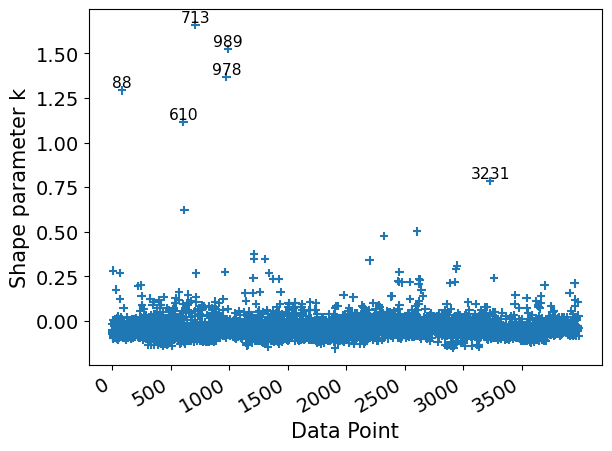

In [53]:
%time
khats = az.loo(m1_infdata, pointwise=True).pareto_k

az.plot_khat(khats, xlabels=True, threshold=0.7)

Plot pointwise elpd differences between two or more models

/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: invalid value encountered in double_scalars
  sigma = -k_post / b_post
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: inv

CPU times: user 59.4 s, sys: 206 ms, total: 59.6 s
Wall time: 59.6 s


<AxesSubplot: title={'center': 'm0 - m1'}, ylabel='ELPD difference'>

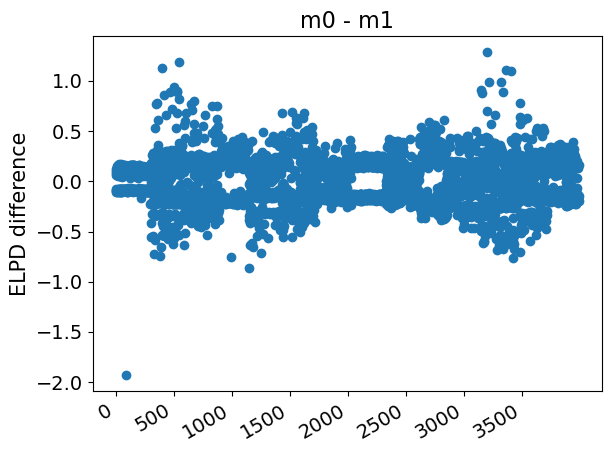

In [52]:
%time
az.plot_elpd({"m0": m0_infdata, "m1": m1_infdata}, xlabels=True)

Here we used a very simple soluation: removing the outliers and re-calculate the `loo`.

In [54]:
%time
loo_m0 = az.loo(m0_infdata, pointwise=True)
loo_m1 = az.loo(m1_infdata, pointwise=True)
loo_m2 = az.loo(m2_infdata, pointwise=True)

/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: invalid value encountered in double_scalars
  sigma = -k_post / b_post
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1035: RuntimeWarning: invalid value encountered in multiply
  k_ary = np.log1p(-b_ary[:, None] * ary).mean(axis=1)  # pylint: disable=no-member
/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1052: RuntimeWarning: inv

CPU times: user 32.8 s, sys: 5.85 ms, total: 32.8 s
Wall time: 32.8 s


In [55]:
outliers0 = loo_m0.pareto_k.where(loo_m0.pareto_k >= 0.7, drop= True).obs_id.values
outliers1 = loo_m1.pareto_k.where(loo_m1.pareto_k >= 0.7, drop= True).obs_id.values
outliers2 = loo_m2.pareto_k.where(loo_m2.pareto_k >= 0.7, drop= True).obs_id.values

# create a index array to remove outliers
outliers = np.unique(np.concatenate((outliers0, outliers1, outliers2), axis=0))
new_indx = data_cavanagh.index.values[~np.isin(data_cavanagh.index.values, outliers)]

In [56]:
%time
m0_infdata = m0_infdata.isel(obs_id=new_indx)
m1_infdata = m1_infdata.isel(obs_id=new_indx)
m2_infdata = m2_infdata.isel(obs_id=new_indx)

CPU times: user 1min 7s, sys: 839 ms, total: 1min 8s
Wall time: 1min 8s


In [57]:
compare_dict2 = {
  "m0(delete outliers)":m0_infdata,
  "m1(delete outliers)":m1_infdata,
  "m2(delete outliers)":m2_infdata
}

In [59]:
comp_loo2 = az.compare(compare_dict2, ic='loo', scale="deviance")
comp_loo2

/opt/conda/lib/python3.9/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m2(delete outliers),0,10808.915163,55.260694,0.000000,0.457117,124.548105,0.000000,False,deviance
m1(delete outliers),1,10810.492096,60.300720,1.576933,0.466414,124.385197,5.824723,False,deviance
m0(delete outliers),2,10988.056578,46.225694,179.141414,0.076469,121.572323,28.273501,False,deviance


## <a id='toc1_6_'></a>[Posterior predictive check](#toc0_)

First, let's spend some time generating posterior predictions. Note that we set `n_ppc` is 500 means we generate 500 samples for each draws in each parameters. 

In [63]:
%time
m0_infdata = m0.to_infdata(loglike = True, ppc = True, n_ppc = 500, save_name = "model_fitted/m0")
m1_infdata = m1.to_infdata(loglike = True, ppc = True, n_ppc = 500, save_name = "model_fitted/m1")
m2_infdata = m2.to_infdata(loglike = True, ppc = True, n_ppc = 500, save_name = "model_fitted/m2")

The time of calculation of loglikelihood took 0.000 seconds
Start generating posterior prediction...
The time of generating PPC took 108.211 seconds
Start converting to InferenceData...
The time of calculation of loglikelihood took 0.000 seconds
Start generating posterior prediction...
The time of generating PPC took 139.313 seconds
Start converting to InferenceData...
The time of calculation of loglikelihood took 0.000 seconds
Start generating posterior prediction...
The time of generating PPC took 122.651 seconds
Start converting to InferenceData...
CPU times: user 6min 35s, sys: 37.4 s, total: 7min 12s
Wall time: 9min 23s


Then, we can plot the ppc by setting different coordinates. 

- Here we demonstrate plotting both the individual leve, `subj_idx` is 3, 11
- and the experimental condition level, `conf` is LC and HC. 

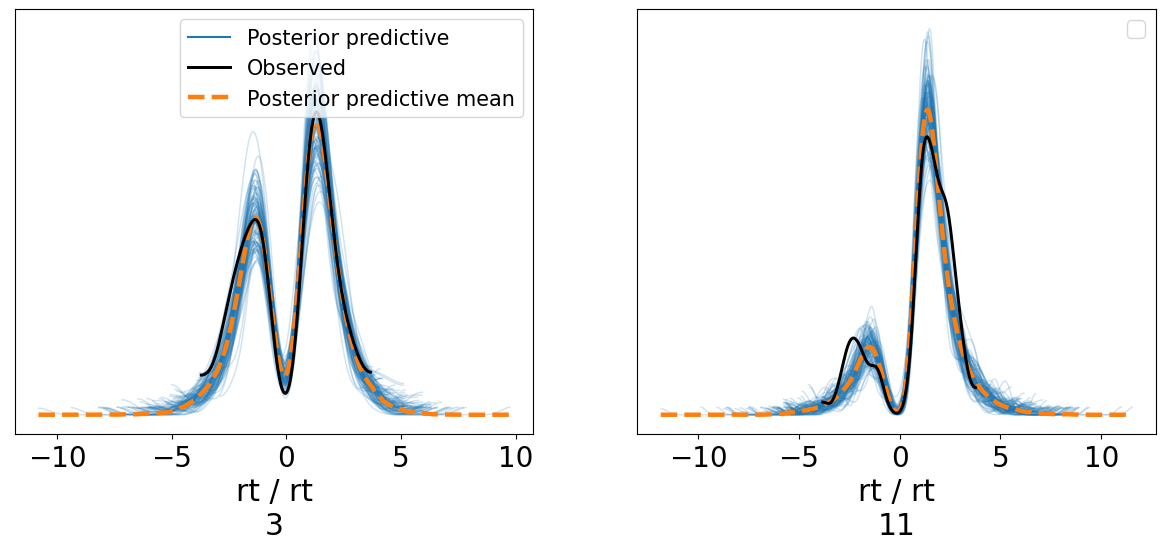

In [64]:
# reset coordinates
m0_infdata = m0_infdata.assign_coords(
  obs_id=m0_infdata.observed_data.coords['subj_idx'].values, 
  groups="observed_vars")

# plot ppc for subj_idx (obs_id) is 0,1,2 and 3
axes = az.plot_ppc(
    m0_infdata, 
    var_names= 'rt', 
    coords={'obs_id': [3,11]}, 
    num_pp_samples=100,
    random_seed = 2023, 
    flatten=[], 
    # legend=False,
    textsize=20, 
    alpha = 0.2
)

In [ ]:
# render figure for manuscript
axes.ravel()[0].figure.savefig("fig_ppc_m0_by_subject.pdf")

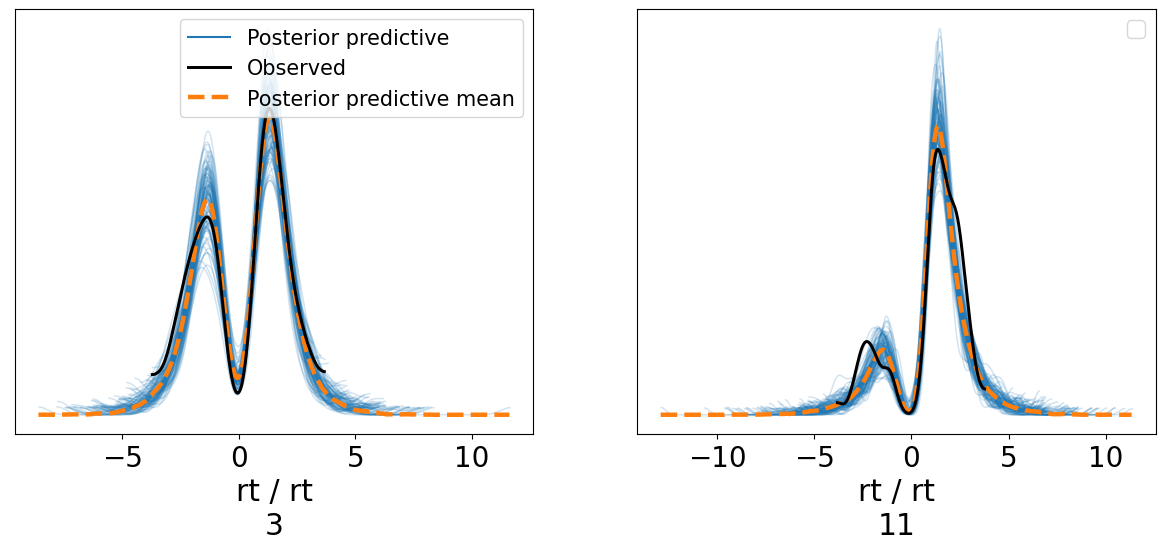

In [65]:
# reset coordinates
m2_infdata = m2_infdata.assign_coords(
  obs_id=m2_infdata.observed_data.coords['subj_idx'].values, 
  groups="observed_vars")

# plot ppc for subj_idx (obs_id) is 0,1,2 and 3
axes = az.plot_ppc(
    m2_infdata, 
    var_names= 'rt', 
    coords={'obs_id': [3, 11]}, 
    num_pp_samples=100, 
    random_seed = 2023, 
    flatten=[], 
    # legend=False,
    textsize=20, 
    alpha = 0.2
)

In [ ]:
# render figure for manuscript
axes.ravel()[0].figure.savefig("fig_ppc_m2_by_subject.pdf")

It is found that model 2 generate more similar predictions to observed data, especially for subject 11. 

Then, let us plot ppc on different conditions. 

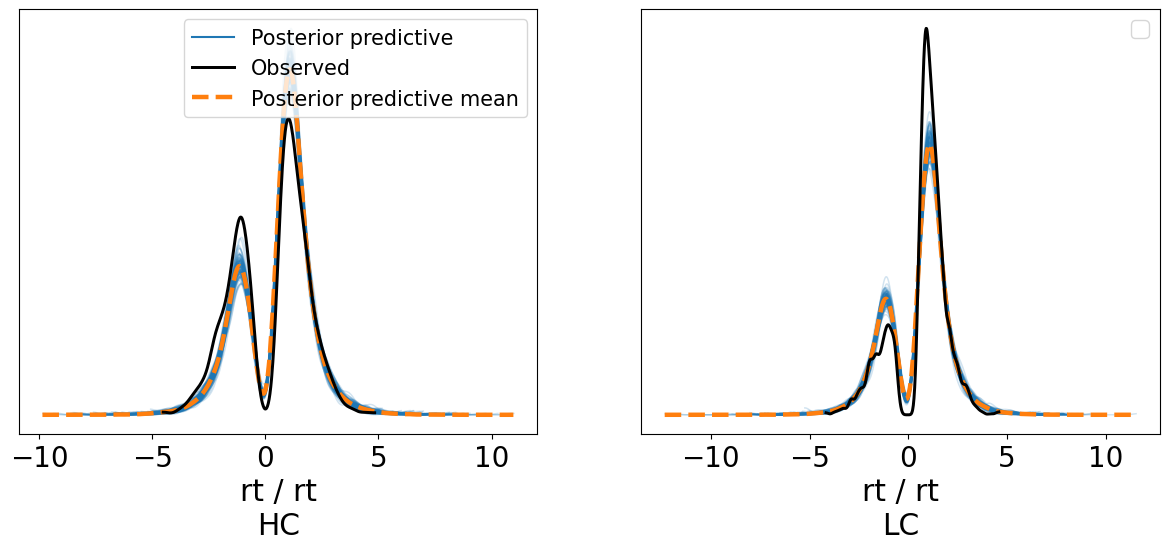

In [66]:
# reset coordinates
m0_infdata = m0_infdata.assign_coords(
  obs_id=m0_infdata.observed_data.variables['conf'].values, 
  groups="observed_vars")


# plot ppc by conditions
axes = az.plot_ppc(
    m0_infdata, 
    var_names= 'rt', 
    coords={'obs_id': ["LC", "HC"]}, 
    num_pp_samples=100, 
    random_seed = 2023, 
    flatten=[], 
    # legend=False,
    textsize=20, 
    alpha = 0.2
)

In [ ]:
# render figure for manuscript
axes.ravel()[0].figure.savefig("fig_ppc_m0_by_condition.pdf")

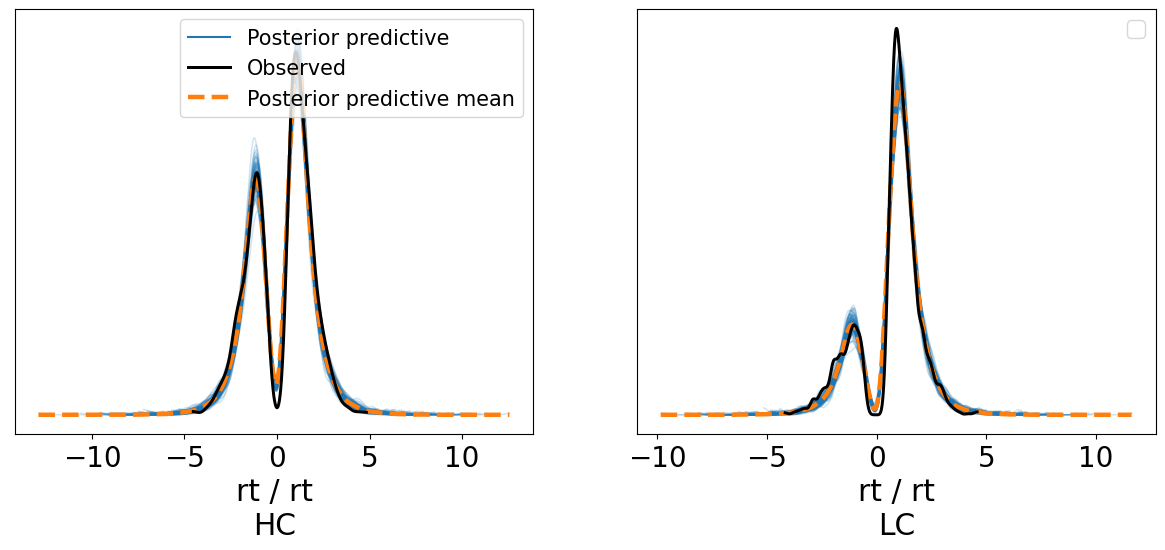

In [67]:
# reset coordinates
m2_infdata = m2_infdata.assign_coords(
  obs_id=m2_infdata.observed_data.variables['conf'].values, 
  groups="observed_vars")


# plot ppc by conditions
axes = az.plot_ppc(
    m2_infdata, 
    var_names= 'rt', 
    coords={'obs_id': ["LC", "HC"]}, 
    num_pp_samples=100, 
    random_seed = 2023, 
    flatten=[], 
    # legend=False,
    textsize=20, 
    alpha = 0.2
)

In [ ]:
# render figure for manuscript
axes.ravel()[0].figure.savefig("fig_ppc_m2_by_condition.pdf")

model 2 get better predictions for both conflict condition (LC vs. HC), given that model 0 did not consider the impact from conflict condition. 

### <a id='toc1_6_1_'></a>[Custom PPC plotting function](#toc0_)

To make it easier to plot ppc under different conditions, we define a function plot_ppc_by_cond, demonstrated as follows.

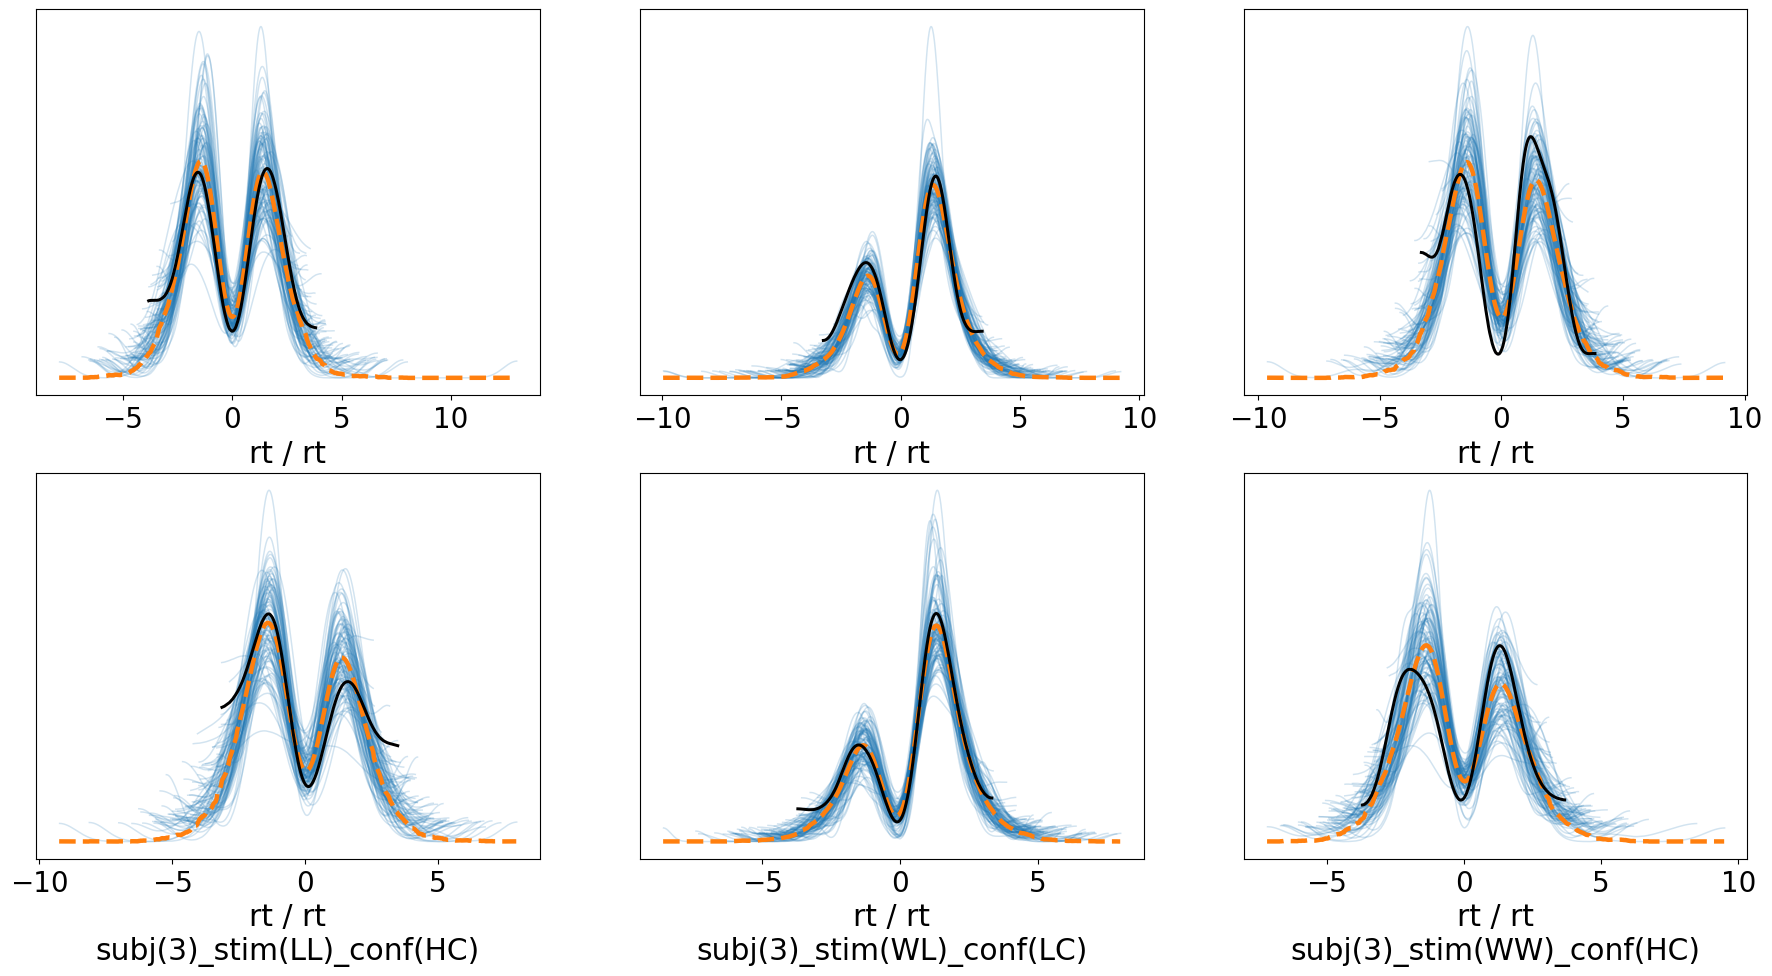

In [70]:
from kabuki.analyze import plot_ppc_by_cond
# examples

# # only consider all subjects
# plot_ppc_by_cond(
#     infdata,
#     num_pp_samples=100,
#     random_seed=2024,
#     legend=False,
#     textsize=20,
#     alpha=0.2
# )
# plt.show()

# # select few subjects
# subj_idx = [0, 3]
# plot_ppc_by_cond(infdata,
#                  subj_idx=subj_idx,
#                  num_pp_samples=100,
#                  random_seed=2024,
#                  legend=False,
#                  textsize=20,
#                  alpha=0.2)
# plt.show()

# # only condition group
# condition_vars = "conf"
# plot_ppc_by_cond(infdata,
#                  condition_vars=condition_vars,
#                  num_pp_samples=100,
#                  random_seed=2024,
#                  legend=False,
#                  textsize=20,
#                  alpha=0.2)
# plt.show()

# # two condition group
# condition_vars = ["conf", "stim"]
# plot_ppc_by_cond(infdata,
#                  condition_vars=condition_vars,
#                  num_pp_samples=100,
#                  random_seed=2024,
#                  legend=False,
#                  textsize=20,
#                  alpha=0.2)
# plt.show()

# # select condition level
# subj_idx = [0, 3]
# condition_vars = {"stim": ["LL", "WW"]}
# plot_ppc_by_cond(infdata,
#                  condition_vars=condition_vars,
#                  num_pp_samples=100,
#                  random_seed=2024,
#                  legend=False,
#                  textsize=20,
#                  alpha=0.2)
# plt.show()

# # select subjects and condition level
# condition_vars = {"stim": ["LL", "WW"]}
# subj_idx = [0, 3]
# plot_ppc_by_cond(infdata,
#                  subj_idx = subj_idx,
#                  condition_vars=condition_vars,
#                  num_pp_samples=100,
#                  random_seed=2024,
#                  legend=False,
#                  textsize=20,
#                  alpha=0.2)
# plt.show()

# more examples
condition_vars = ['stim','conf']
subj_idx = [0, 3]
plot_ppc_by_cond(m2_infdata,
                 subj_idx=subj_idx,
                 condition_vars=condition_vars,
                 num_pp_samples=100,
                 random_seed=2024,
                 legend=False,
                 textsize=20,
                 alpha=0.2)
# Increase line spacing to avoid xlabel being obscured
plt.subplots_adjust(hspace=0.3)
plt.show()

## <a id='toc1_7_'></a>[Statistical Inference](#toc0_)

Here we onlyu examplified how to us ROPE + HDI method. 

- Assume that we are interested in the effect of conflit level on drift rate `v` and we used [-0.2, 0.2] as the ROPE. 
- Then we can used visualize the ROPE and HDI with `az.plot_posterior()`.

(-0.9, 0.3)

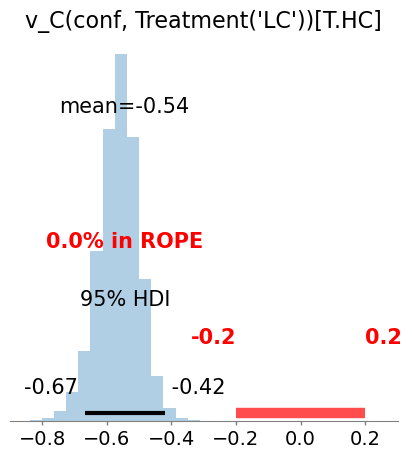

In [56]:
# using regex to select var_names that start with "a_theta" and do not contain either "subj" or "std"
axes = az.plot_posterior(
    m2_infdata,
    var_names=("v_C(conf, Treatment('LC'))[T.HC]"),
    kind = 'hist',
    hdi_prob = 0.95,
    rope = [-0.2, 0.2], # assume this is our ROPE
    textsize=14, 
    rope_color = 'r',
    figsize = (5,5)
)
axes.set_xlim(-0.9,0.3)

In [57]:
# render figure for manuscript
axes.figure.savefig("fig_posterior_inference_m2_drift_rate_on_conflict.pdf")

It is easy to find that the drift rate in HC is lower than it in LC. 

Then we plot the posteriors distribution of drift rates in both condition to reaffirm this results. 

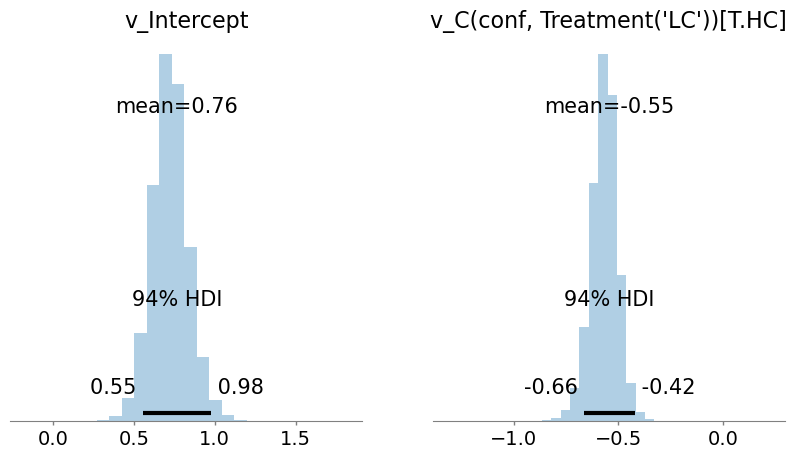

In [72]:
# plot posterior histgram by conditions, 
# v_Intercept represent v in LC 
# and v_C(conf, Treatment('LC'))[T.HC] represent v in HC. 
axes = az.plot_posterior(
    m2_infdata, 
    var_names=("^v(?!.*(subj|std))"), 
    filter_vars='regex', 
    kind='hist',
    figsize = (10,5)
)

In [73]:
m2_infdata.posterior["v_HC"] = (
    ("chain", "draw"),
    m2_infdata.posterior["v_Intercept"].values + \
    m2_infdata.posterior["v_C(conf, Treatment('LC'))[T.HC]"].values)
m2_infdata.posterior["v_LC"] = (
    ("chain", "draw"),
    m2_infdata.posterior["v_Intercept"].values)

Compare posterior using plot_forest. See [`az.plot_forest`](https://python.arviz.org/en/latest/api/generated/arviz.plot_forest.html#arviz.plot_forest) for more.

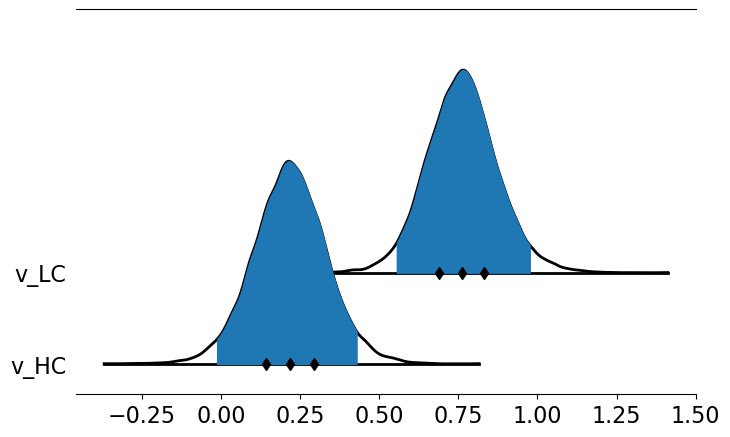

In [74]:
 # plot posterior forest distriution by conditions
axes = az.plot_forest(
    m2_infdata,
    kind='ridgeplot',
    var_names=("v_LC", "v_HC"), 
    linewidth=2,
    ridgeplot_overlap=3,
    ridgeplot_truncate=False,
    ridgeplot_quantiles=[.25, .5, .75],
    combined=True,
    figsize=(8, 5)
 )

Similarly, violin plot can also be used:

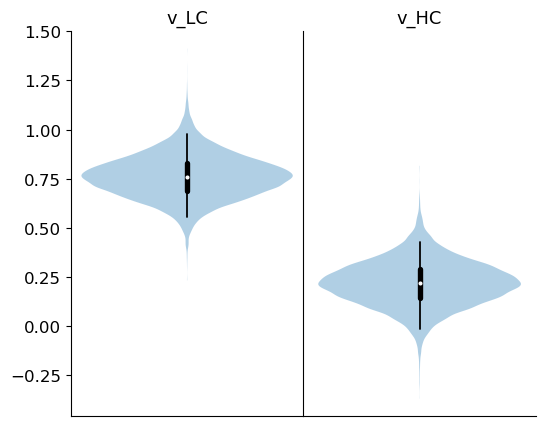

In [75]:
import seaborn as sns
# plot posterior violin plot by conditions
axes = az.plot_violin(
    m2_infdata, 
    var_names=("v_LC", "v_HC"), 
    figsize=(6, 5),
    textsize=12
)

sns.despine()

In [ ]:
# render figure for manuscript
axes.ravel()[0].figure.savefig("fig_posterior_inference_m2_drift_rate_on_conflict_violin.pdf")

If we have prior samples in inferenceData especially when we set `sample_prior = True` in `to_infdata` or `sample` methods. We could use `az.plot_bf` to calculate Savage-Dickey Density Ratio to approximate the Bayes Factor. 

In [48]:
m2_infdata = m2.to_infdata(sample_prior=True, save_name = "model_fitted/m2")

Start converting to InferenceData...


The reference value is outside of the posterior. This translate into infinite support for H1, which is most likely an overstatement.


(-1.0, 0.5)

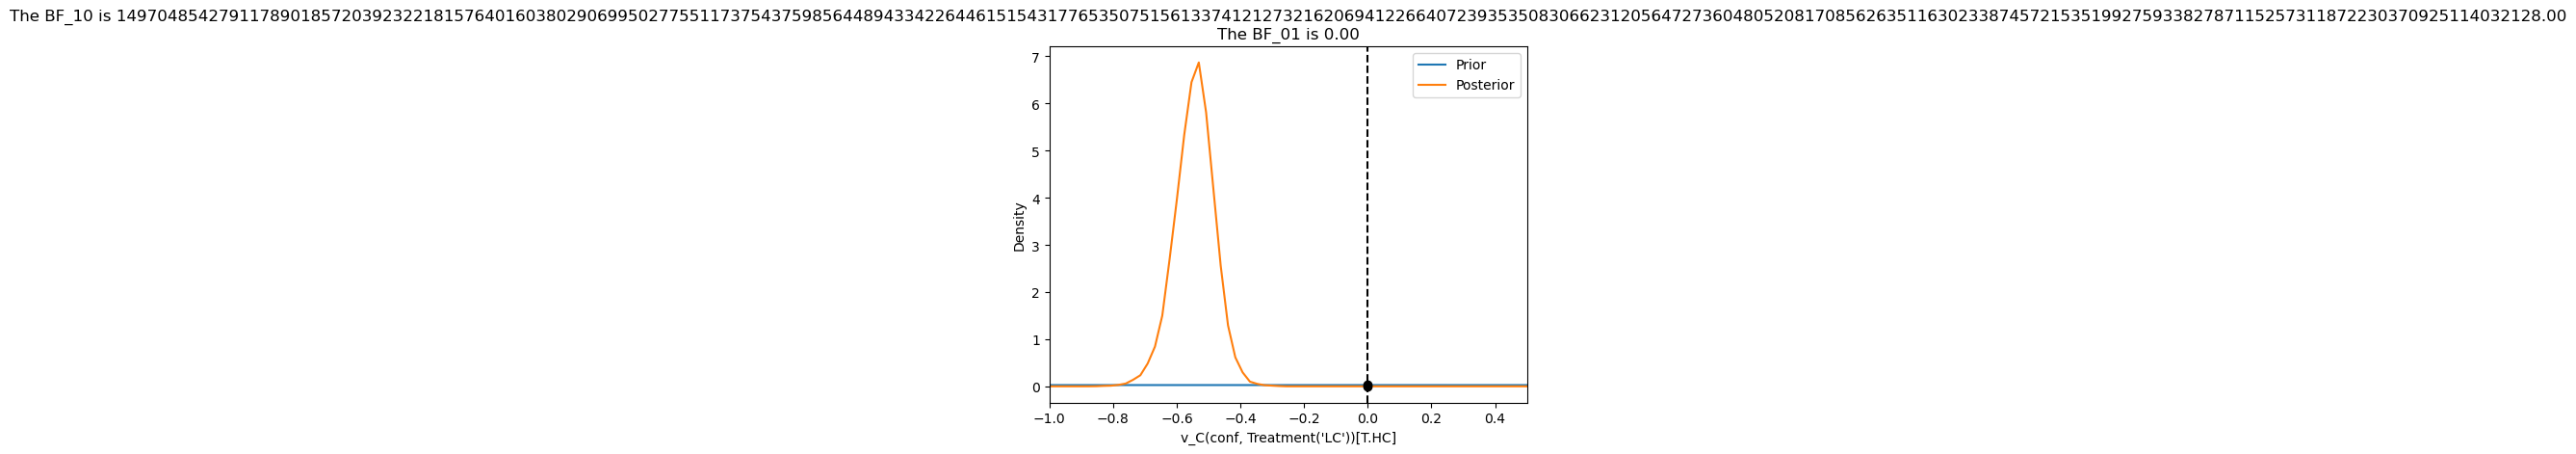

In [179]:
import matplotlib.pyplot as plt
ax = az.plot_bf(
    m2_infdata,
    var_name="v_C(conf, Treatment('LC'))[T.HC]",
    ref_val = 0
)
plt.xlim(-1,0.5)

In [64]:
# render figure for manuscript
ax[1].get_figure().savefig("fig_posterior_inference_m2_drift_rate_on_conflict_bf.pdf")

(0.3, 0.7)

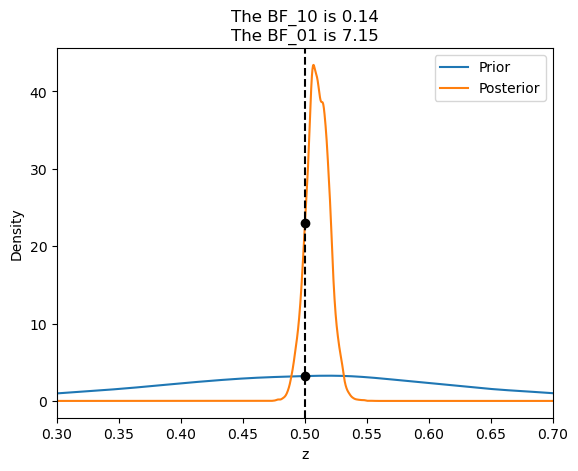

In [177]:
import matplotlib.pyplot as plt
ax = az.plot_bf(
    m2_infdata,
    var_name="z",
    ref_val = 0.5
)
plt.xlim(0.3,0.7)

In [175]:
# render figure for manuscript
ax[1].get_figure().savefig("fig_posterior_inference_m2_z_bf.pdf")